:# Healthy‐Trained 3D Autoencoder with MBConv, Early Stopping and Anomaly Inference

In [1]:
!rm -rf /content/data/

In [1]:
#Prepare Colab for work

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#copy dataset to /content for faster access  on colab!
!mkdir /content/data
!cp -r "/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/IXI-T1_resampled" /content/data/IXI-T1_resampled/
!cp -r "/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/T1_tumor_resampled" /content/data/T1_tumor_resampled/
#!cp -r "/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/T1Gd_tumor_resampled" /content/data/T1Gd_tumor_resampled/
!cp -r "/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/Tumor_labels_resampled" /content/data/Tumor_labels_resampled/


In [4]:
!pip install SimpleITK scikit-learn piqa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
!nvidia-smi

Thu Jun 19 15:12:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:

import os
import numpy as np
import SimpleITK as sitk
from glob import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
#import piqa
from piqa import SSIM
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt


In [ ]:
#test cell
#array_np = sitk.GetArrayFromImage(sitk.ReadImage('/content/data/T1_tumor_resampled/BRATS_001_T1.nii.gz'))
#array_np = sitk.GetArrayFromImage(sitk.ReadImage('/content/data/Tumor_labels_resampled/BRATS_001.nii.gz'))
#array_np = sitk.GetArrayFromImage(sitk.ReadImage('/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_043_T1_ep28_tumor_anomaly_mask.nii.gz'))
array_np = sitk.GetArrayFromImage(sitk.ReadImage('/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_043_T1_ep28_tumor_anomaly_mask.nii.gz'))
print('unique values: ', np.unique(array_np))
print(f'min, max: {np.min(array_np), np.max(array_np)}')


unique values:  [0 1]
min, max: (np.uint8(0), np.uint8(1))


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MBConv3D(nn.Module):
    """
    Mobile Inverted Bottleneck Convolution (MBConv) block for 3D data.
    Implementation: expansion -> depthwise conv -> projection with optional residual.
    """
    def __init__(self, in_channels, out_channels, expansion=4, stride=1):
        super(MBConv3D, self).__init__()
        hidden_dim = in_channels * expansion
        self.use_residual = (stride == 1 and in_channels == out_channels)

        # 1) expand
        self.expand_conv = nn.Conv3d(in_channels, hidden_dim, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(hidden_dim)
        # 2) depthwise
        self.dw_conv = nn.Conv3d(
            hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1,
            groups=hidden_dim, bias=False
        )
        self.bn2 = nn.BatchNorm3d(hidden_dim)
        # 3) project
        self.project_conv = nn.Conv3d(hidden_dim, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_channels)

        self.act = nn.SiLU()

    def forward(self, x):
        out = self.act(self.bn1(self.expand_conv(x)))
        out = self.act(self.bn2(self.dw_conv(out)))
        out = self.bn3(self.project_conv(out))
        if self.use_residual:
            return out + x
        return out

class VAE3D_MBConv(nn.Module):
    def __init__(self, in_channels=1, latent_dim=128, exp_factor=2):
        super(VAE3D_MBConv, self).__init__()
        # Encoder: MBConv blocks with downsampling
        self.enc1 = MBConv3D(in_channels, 32, expansion=exp_factor, stride=1)
        self.enc2 = MBConv3D(32, 64, expansion=exp_factor, stride=2)
        self.enc3 = MBConv3D(64, 128, expansion=exp_factor, stride=2)
        self.enc4 = MBConv3D(128, 256, expansion=exp_factor, stride=2)

        # Bottleneck: global pool -> latent vectors
        self.avgpool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder: project latent -> feature map then upsample
        self.decoder_input = nn.Linear(latent_dim, 256)
        # We'll upsample 3 times (stride=2) to invert the encoder
        self.up1 = nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1)
        self.mb1 = MBConv3D(128, 128, expansion=exp_factor, stride=1)
        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1)
        self.mb2 = MBConv3D(64, 64, expansion=exp_factor, stride=1)
        self.up3 = nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1)
        self.mb3 = MBConv3D(32, 32, expansion=exp_factor, stride=1)
        # final conv: reconstruct to 1 channel
        self.final_conv = nn.Conv3d(32, in_channels, kernel_size=1)

        self.act = nn.SiLU()

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        mu     = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, target_shape):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 1, 1, 1)
        x = self.act(self.up1(x))
        x = self.mb1(x)
        x = self.act(self.up2(x))
        x = self.mb2(x)
        x = self.act(self.up3(x))
        x = self.mb3(x)
        x = self.final_conv(x)
        if x.shape[2:] != target_shape:
            x = F.interpolate(x, size=target_shape, mode='trilinear', align_corners=False)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, target_shape=x.shape[2:])
        return recon, mu, logvar


In [7]:

class HealthyNiftiDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = sitk.ReadImage(self.paths[idx])
        arr = sitk.GetArrayFromImage(img).astype(np.float32)  # [D, H, W]
        # Z-score → min-max normalize to [0,1]
        mean, std = arr.mean(), arr.std()
        norm = (arr - mean) / (std + 1e-5)
        norm = (norm - norm.min()) / (norm.max() - norm.min() + 1e-5)
        norm = np.clip(norm, 0.0, 1.0)
        return torch.tensor(norm[None, ...], dtype=torch.float32)


In [8]:

# Paths to healthy volumes (update these)
#healthy_paths = sorted(glob("IXI-T1_resampled/*.nii.gz"))
t1_files = sorted(glob(r'/content/data/IXI-T1_resampled/*.nii.gz'))
#t2_files = sorted(glob("/mnt/data/IXI-T2_resampled/*.nii.gz"))
healthy_paths = t1_files # + t2_files
#healthy_paths = sorted(glob("IXI-T1_resampled/*.nii.gz"))
# Split into train/val
train_paths, val_paths = train_test_split(healthy_paths, test_size=0.2, random_state=42)

train_ds = HealthyNiftiDataset(train_paths)
val_ds   = HealthyNiftiDataset(val_paths)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
# Model, optimizer, loss, SSIM for VAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE3D_MBConv().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
mse_loss = nn.MSELoss()
ssim_loss = SSIM(n_channels=1).to(device)
beta = 1.0
writer = SummaryWriter(log_dir=f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_Healthy_T1_1ch_BEST_With_MBConv")


In [ ]:
# Training with early stopping for VAE
patience = 5
best_val_loss = float("inf")
epochs_without_improvement = 0
n_epochs = 50
train_losses, val_losses = [], []

for epoch in range(1, n_epochs + 1):
    model.train()
    train_epoch_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        recon_clamped = torch.clamp(recon, 0.0, 1.0)
        mse = mse_loss(recon, batch)
        ssim = ssim_loss(recon_clamped, batch)
        kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = 0.8 * mse + 0.2 * (1 - ssim) + beta * kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    # Validation loop
    model.eval()
    val_epoch_loss = 0.0
    with torch.no_grad():
        for vbatch in val_loader:
            vbatch = vbatch.to(device)
            recon, mu, logvar = model(vbatch)
            recon_clamped = torch.clamp(recon, 0.0, 1.0)
            mse = mse_loss(recon, vbatch)
            ssim = ssim_loss(recon_clamped, vbatch)
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = 0.8 * mse + 0.2 * (1 - ssim) + beta * kld
            val_epoch_loss += loss.item()
        val_epoch_loss /= len(val_loader)

    avg_train_loss = train_epoch_loss / len(train_loader)
    print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_epoch_loss:.4f}")

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        epochs_without_improvement = 0
        model_path = f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv_Healthy_T1_1ch_ep{epoch}_loss{val_epoch_loss:.4f}.pt"
        torch.save(model.state_dict(), model_path)
        print("  ✔️ Validation improved; model saved.")
    else:
        epochs_without_improvement += 1
        print(f"  ❌ No improvement for {epochs_without_improvement}/{patience} epochs.")
        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch}.")
            break


Epoch 01 | Train Loss: 0.1275 | Val Loss: 0.1184
  ✔️ Validation improved; model saved.
Epoch 02 | Train Loss: 0.1017 | Val Loss: 0.1140
  ✔️ Validation improved; model saved.
Epoch 03 | Train Loss: 0.1010 | Val Loss: 0.1134
  ✔️ Validation improved; model saved.
Epoch 04 | Train Loss: 0.1007 | Val Loss: 0.1104
  ✔️ Validation improved; model saved.
Epoch 05 | Train Loss: 0.1006 | Val Loss: 0.1088
  ✔️ Validation improved; model saved.
Epoch 06 | Train Loss: 0.1006 | Val Loss: 0.1114
  ❌ No improvement for 1/5 epochs.
Epoch 07 | Train Loss: 0.1005 | Val Loss: 0.1092
  ❌ No improvement for 2/5 epochs.
Epoch 08 | Train Loss: 0.1004 | Val Loss: 0.1096
  ❌ No improvement for 3/5 epochs.
Epoch 09 | Train Loss: 0.1004 | Val Loss: 0.1143
  ❌ No improvement for 4/5 epochs.
Epoch 10 | Train Loss: 0.1003 | Val Loss: 0.1126
  ❌ No improvement for 5/5 epochs.
Stopping early at epoch 10.


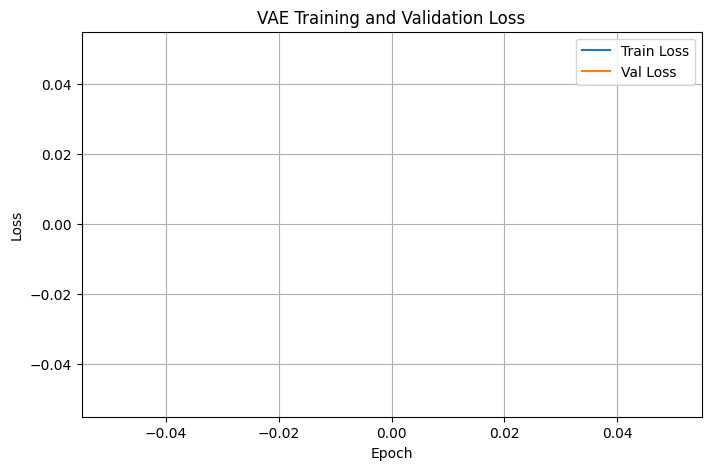

In [ ]:

# Plot training and validation loss curves
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(r"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv_Healthy_T1_1ch.png")
plt.show()


# Inference starts here

In [9]:
# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE3D_MBConv().to(device)

In [10]:
#Paths

epoch_num = 5 #46 last
model_path = f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv/VAE_MBConv_Healthy_T1_1ch_ep5_loss0.1088.pt"
infer_num = '043'
scan_type = 'T1' #'T1Gd'
input_img = f"BRATS_{infer_num}_{scan_type}.nii.gz"
tumor_path = f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/{scan_type}_tumor_resampled/{input_img}"

tumor_path


'/content/drive/MyDrive/00-DataScience_BIU/Final Project/data/T1_tumor_resampled/BRATS_043_T1.nii.gz'

In [11]:
# Load best model for inference
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE3D_MBConv().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

<All keys matched successfully>

In [12]:
import SimpleITK as sitk

# Inference on a tumor case (update path)
tumor_img = sitk.ReadImage(tumor_path)
tumor_arr = sitk.GetArrayFromImage(tumor_img).astype(np.float32)
mean, std = tumor_arr.mean(), tumor_arr.std()
norm = (tumor_arr - mean) / (std + 1e-5)
norm = (norm - norm.min()) / (norm.max() - norm.min() + 1e-5)
norm = np.clip(norm, 0.0, 3.0)

print(f'unique: {np.unique(norm)}')
print(f'min, max: {np.min(norm), np.max(norm)}')

with torch.no_grad():
    inp = torch.tensor(norm[None, None, ...], dtype=torch.float32).to(device)
    recon, mu, logvar = model(inp)
    out = recon.cpu().numpy()[0, 0]

# Denormalize and compute error map
recon = out * (std + 1e-5) + mean
err_map = np.abs(tumor_arr - recon)

# Save reconstructed volume
recon_itk = sitk.GetImageFromArray(recon.astype(np.float32))
recon_itk.SetOrigin(tumor_img.GetOrigin())
recon_itk.SetSpacing(tumor_img.GetSpacing())
recon_itk.SetDirection(tumor_img.GetDirection())
sitk.WriteImage(recon_itk, f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv/VAE_MBConv_{infer_num}_{scan_type}_ep{epoch_num}_recon.nii.gz")


# Save error map
err_itk = sitk.GetImageFromArray(err_map.astype(np.float32))
err_itk.SetOrigin(tumor_img.GetOrigin())
err_itk.SetSpacing(tumor_img.GetSpacing())
err_itk.SetDirection(tumor_img.GetDirection())
sitk.WriteImage(err_itk, f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv/VAE_MBConv_{infer_num}_{scan_type}_ep{epoch_num}_tumor_error_map.nii.gz")

# Threshold at 99.5th percentile
#thresh = np.percentile(err_map, 99.5)
#mask = (err_map >= thresh).astype(np.uint8)

#---------------------------
# Define custom high-end percentiles
p1 = np.percentile(err_map, 99.2)   # High error
p2 = np.percentile(err_map, 99.5)   # Very high error
p3 = np.percentile(err_map, 99.8)  # Extreme error

# Initialize mask as background
mask = np.zeros_like(err_map, dtype=np.uint8)

# Assign class labels
mask[(err_map >= p1) & (err_map < p2)] = 3   # High error Red=1
mask[(err_map >= p2) & (err_map < p3)] = 2   # Very high error Green=2
mask[err_map >= p3] = 1                      # Extreme error Blue=3
#---------------------------


# Save binary anomaly mask
mask_itk = sitk.GetImageFromArray(mask)
mask_itk.SetOrigin(tumor_img.GetOrigin())
mask_itk.SetSpacing(tumor_img.GetSpacing())
mask_itk.SetDirection(tumor_img.GetDirection())
sitk.WriteImage(mask_itk, f"/content/drive/MyDrive/00-DataScience_BIU/Final Project/VAE_Healthy/VAE_MBConv/VAE_MBConv_{infer_num}_{scan_type}_ep{epoch_num}_tumor_anomaly_mask.nii.gz")

#print(f"Threshold used: {thresh:.4f}")

unique: [0.0000000e+00 8.4338290e-06 1.9073363e-05 ... 9.8204428e-01 9.8655808e-01
 9.9999857e-01]
min, max: (np.float32(0.0), np.float32(0.99999857))


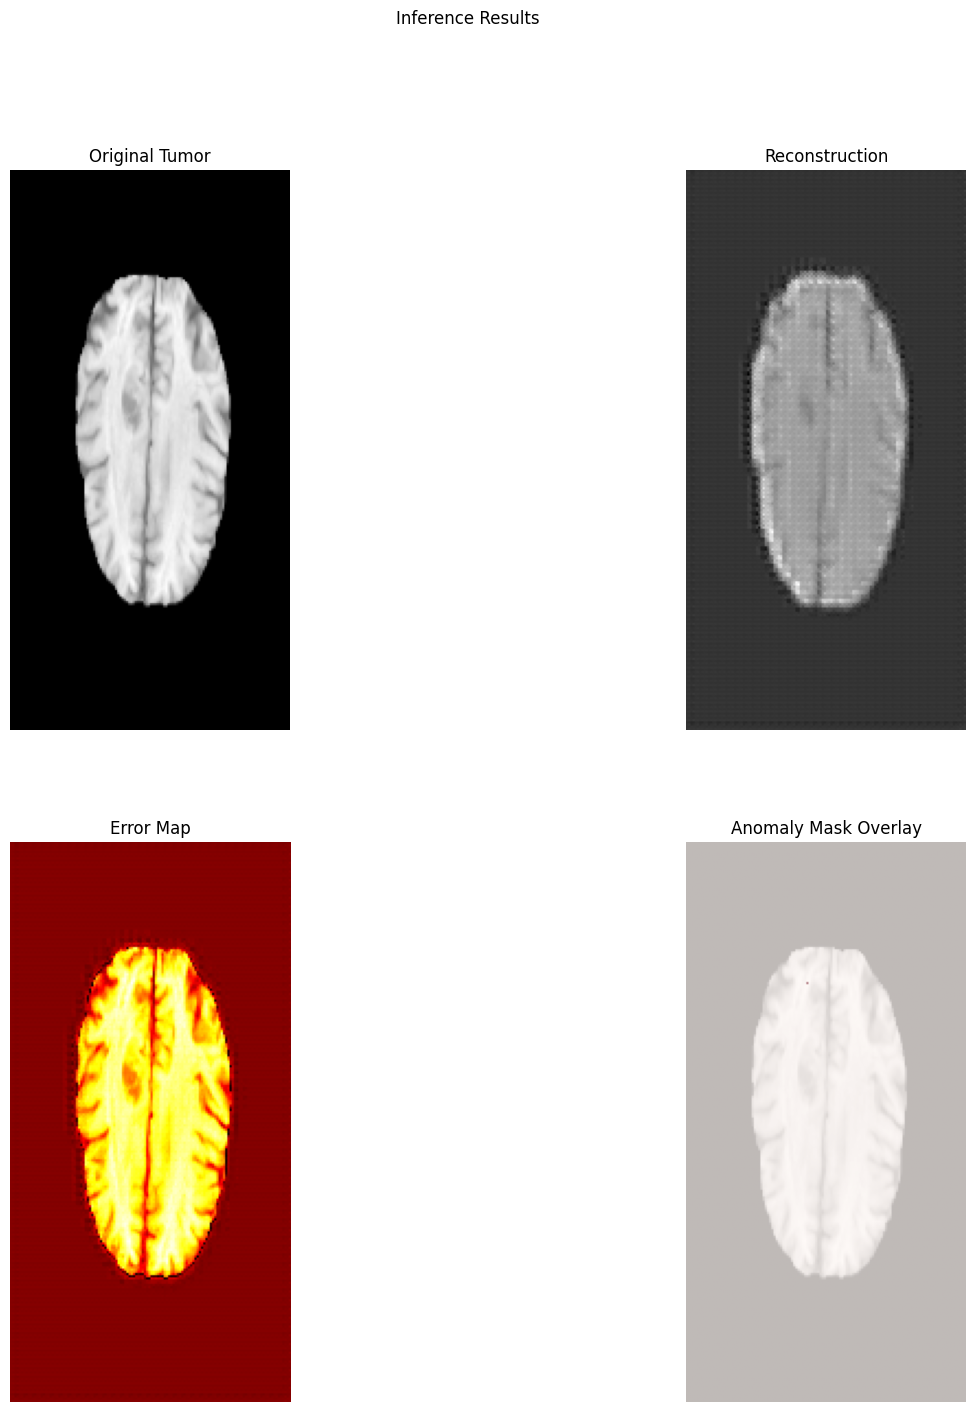

In [ ]:

# Visualize center slice of original, reconstruction, error, and mask
slice_idx = 154 # tumor_arr.shape[0] // 2

plt.figure(figsize=(16,16))

plt.subplot(2,2,1)
plt.imshow(tumor_arr[slice_idx], cmap='gray')
plt.title("Original Tumor")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(recon[slice_idx], cmap='gray')
plt.title("Reconstruction")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(err_map[slice_idx], cmap='hot')
plt.title("Error Map")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(tumor_arr[slice_idx], cmap='gray', alpha=0.5)
plt.imshow(mask[slice_idx], cmap='Reds', alpha=0.5)
plt.title("Anomaly Mask Overlay")
plt.axis('off')

plt.suptitle("Inference Results")
plt.savefig("tumor_inference_visual.png")
plt.show()
